In [1]:
# 데이터 파일 경로 설정 (노트북 기준 상위 폴더의 data/ 안에 위치)
from pathlib import Path

DATA_PATH = Path("../data/water_potability.csv")

DATA_PATH.exists()  # 파일이 실제로 존재하는지 확인 (True면 정상)

True

In [2]:
# CSV 파일을 DataFrame으로 읽어오기
import pandas as pd

df = pd.read_csv(DATA_PATH)

In [3]:
df.head()  # 상위 5개 행 미리보기 (컬럼 구성과 값의 형태 확인)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.info()  # 행 수, 컬럼별 결측치(non-null) 개수, 데이터 타입 확인

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
df.describe()  # 수치형 컬럼의 기초 통계량 (평균, 표준편차, 사분위수 등)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [6]:
df.isnull().sum()  # 컬럼별 결측치 개수 집계 (ph, Sulfate, Trihalomethanes에 결측 존재)

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [7]:
df.columns  # 전체 컬럼명 목록 확인

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='str')

In [8]:
# 각 컬럼의 고유값 개수를 세어 수치형/범주형을 구분
# 고유값이 2개뿐인 Potability만 범주형(정답), 나머지는 값이 거의 다 달라 수치형
arr = []

for el in df.columns:
    arr.append(len(df[el].unique()))  # 컬럼별 고유값 개수

arr

[2786, 3276, 3276, 3276, 2496, 3276, 3276, 3115, 3276, 2]

### 정답 y를 제외한 나머지는 수치형 변수

## 컬럼 한글 사전

| 컬럼명 | 한글 의미 | 설명 |
|---|---|---|
| `ph` | 산성도(pH) | 물의 산성/염기성 정도 (0~14, 7이 중성) |
| `Hardness` | 경도 | 칼슘·마그네슘 등 무기질 함량 (mg/L) |
| `Solids` | 총 용존 고형물 | 물에 녹아 있는 전체 고형물량 (ppm) |
| `Chloramines` | 클로라민 | 소독용 염소 화합물 농도 (ppm) |
| `Sulfate` | 황산염 | 물속 황산염 농도 (mg/L) |
| `Conductivity` | 전기전도도 | 이온 농도로 인한 전기 전도 정도 (μS/cm) |
| `Organic_carbon` | 총 유기 탄소 | 유기물 유래 탄소량 (ppm) |
| `Trihalomethanes` | 트리할로메탄 | 염소 소독 부산물 농도 (μg/L) |
| `Turbidity` | 탁도 | 물의 흐림 정도 (NTU) |
| `Potability` | **음용 가능성(정답 y)** | 1 = 마실 수 있음, 0 = 마실 수 없음 |


## EDA 시각화

정답 `Potability`를 제외한 9개 피처는 모두 수치형이다.
분포·이상치·타겟과의 관계·피처 간 관계를 차트로 살펴본다.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn 스타일을 먼저 적용한 뒤 폰트를 설정해야 폰트가 덮어써지지 않음
sns.set_style("whitegrid")

# 한글 폰트 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 깨짐 방지

# 이진 타겟 색상: 고정 순서 (0=비음용 파랑, 1=음용 주황)
PALETTE = {0: "#4C78A8", 1: "#F58518"}
LABELS = {0: "비음용(0)", 1: "음용(1)"}

# 피처 목록 (타겟 제외)
features = [c for c in df.columns if c != "Potability"]
features

['ph',
 'Hardness',
 'Solids',
 'Chloramines',
 'Sulfate',
 'Conductivity',
 'Organic_carbon',
 'Trihalomethanes',
 'Turbidity']

### 0. 타겟 분포 — 음용 가능 비율

정답 `Potability`의 클래스 비율을 확인한다.
한쪽으로 크게 치우쳤다면(불균형) 이후 모델 평가·샘플링 전략에 영향을 준다.

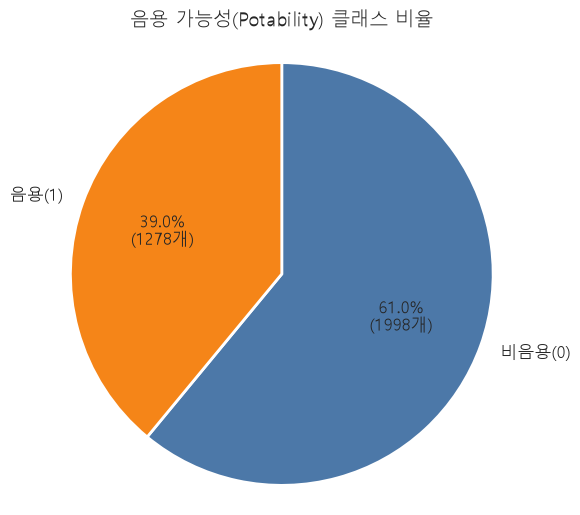

In [10]:
# 타겟(Potability) 클래스별 개수 집계 (인덱스를 0, 1 순서로 정렬)
counts = df["Potability"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    counts,                                          # 각 클래스 개수 → 조각 크기
    labels=[LABELS[i] for i in counts.index],        # 조각 라벨 (비음용/음용)
    colors=[PALETTE[i] for i in counts.index],       # 고정 색상 (0=파랑, 1=주황)
    # 각 조각에 비율(%)과 실제 개수를 함께 표시
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100*counts.sum()))}개)",
    startangle=90,          # 12시 방향에서 시작
    counterclock=False,     # 시계 방향으로 그리기
    wedgeprops=dict(edgecolor="white", linewidth=2),  # 조각 사이 흰색 간격
    textprops=dict(fontsize=12),
)
ax.set_title("음용 가능성(Potability) 클래스 비율", fontsize=14, pad=12)
ax.axis("equal")  # 가로세로 비율을 같게 해 원형 유지
plt.show()

> **인사이트**
> - 비음용(0) **61%** vs 음용(1) **39%** — 다수 클래스가 61%인 **약한 불균형**이다.
> - 아주 심한 불균형은 아니라 오버샘플링 같은 강한 처리는 필수가 아니지만,
>   정확도(accuracy)만 보면 "전부 비음용"으로 찍어도 61%가 나오므로 착시가 생긴다.
> - 따라서 이후 모델 평가는 **AUC, F1, 혼동행렬**을 함께 봐야 하고,
>   기준선(baseline)은 "다수 클래스 예측 = 61%"로 잡는다.

### 1. 히스토그램 그리드 — 피처별 분포

각 피처가 어떤 범위에 어떻게 퍼져 있는지, 치우침(skew)이 있는지 확인한다.

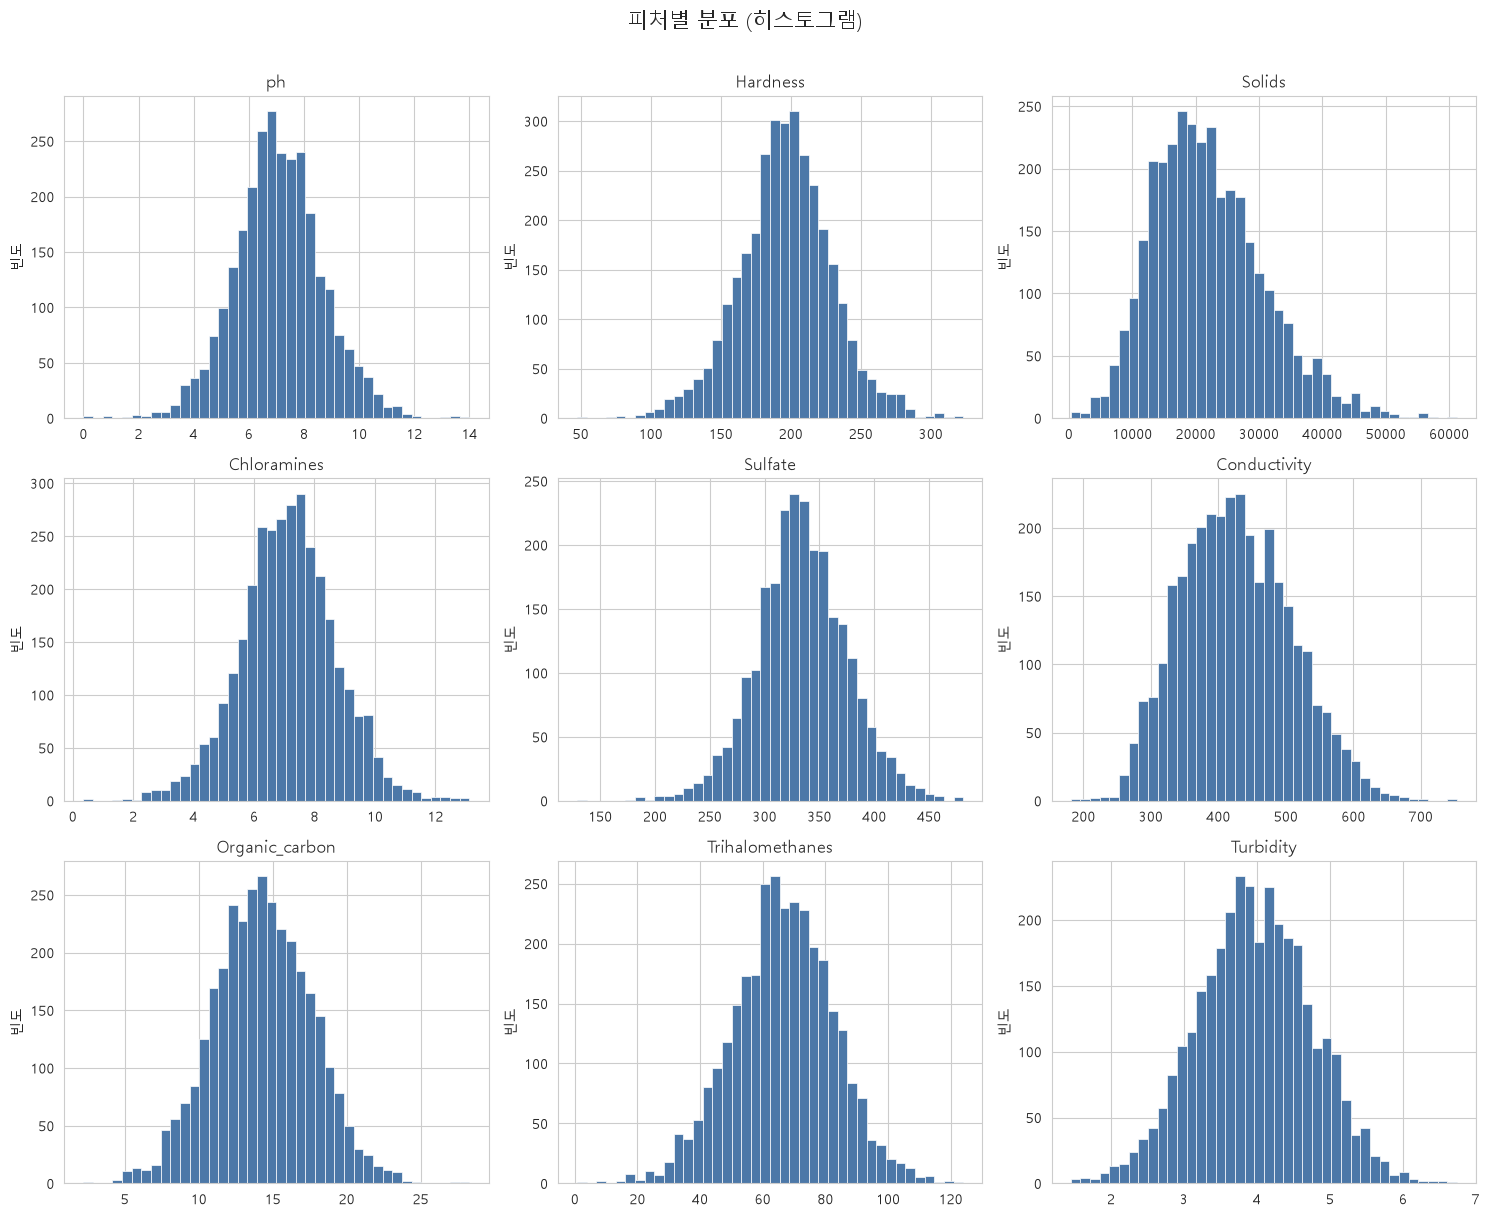

In [11]:
# 9개 피처를 3x3 격자에 히스토그램으로 그리기
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# axes.flat: 2차원 격자를 1차원처럼 순회 → 피처와 하나씩 짝지음
for ax, col in zip(axes.flat, features):
    # dropna(): 결측치는 제외하고 분포를 그림 / bins=40: 구간 40개로 세분화
    ax.hist(df[col].dropna(), bins=40, color="#4C78A8", edgecolor="white", linewidth=0.5)
    ax.set_title(col)
    ax.set_ylabel("빈도")

fig.suptitle("피처별 분포 (히스토그램)", fontsize=15, y=1.01)
fig.tight_layout()  # 서브플롯 간 여백 자동 조정
plt.show()

> **인사이트**
> - 대부분의 피처가 **종 모양(정규분포)에 가깝다** — `Hardness`, `Chloramines`, `Sulfate`, `Conductivity`, `Organic_carbon`, `Trihalomethanes`, `Turbidity`.
> - `Solids`는 오른쪽으로 살짝 **꼬리가 긴(right-skew)** 분포다.
> - `ph`는 0~14 범위에 대칭적으로 퍼져 있다(중앙 7 부근에 집중).
> - 분포가 대체로 정규분포에 가까우므로 **결측치는 평균/중앙값 대치가 무난**하고, 로그 변환 같은 강한 처리는 대부분 불필요하다.

### 2. 박스플롯 그리드 — 이상치 확인

피처마다 스케일이 크게 다르므로 개별 서브플롯으로 그린다.
수염(whisker) 밖의 점들이 이상치 후보다.

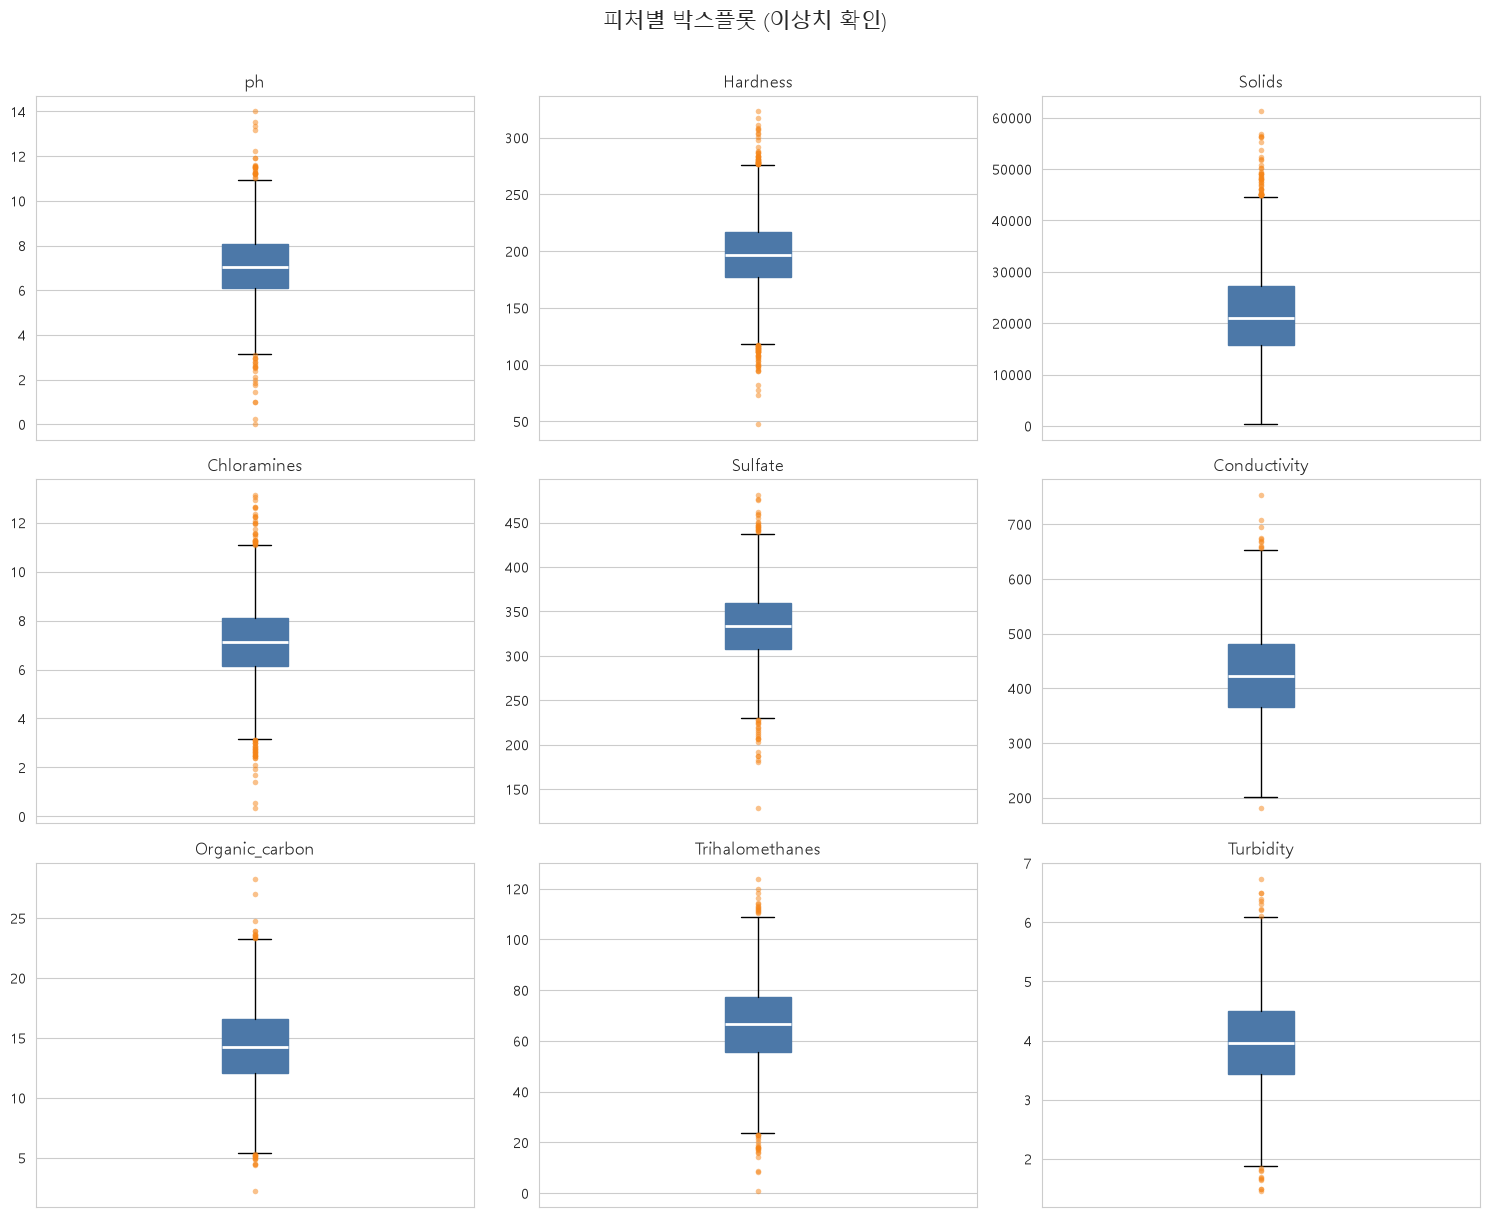

In [12]:
# 9개 피처를 3x3 격자에 박스플롯으로 그리기 (이상치 확인용)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flat, features):
    ax.boxplot(
        df[col].dropna(),              # 결측치 제외
        orientation='vertical',        # 세로 방향 박스
        patch_artist=True,             # 박스 내부를 색으로 채우기 위해 필요
        boxprops=dict(facecolor="#4C78A8", color="#4C78A8"),   # 박스 색상
        medianprops=dict(color="white", linewidth=2),          # 중앙값 선(흰색)
        # 이상치(수염 밖 점)는 주황색 원으로 표시
        flierprops=dict(marker="o", markersize=4, markerfacecolor="#F58518",
                        markeredgecolor="none", alpha=0.5),
    )
    ax.set_title(col)
    ax.set_xticks([])  # x축 눈금 제거 (피처 하나씩이라 불필요)

fig.suptitle("피처별 박스플롯 (이상치 확인)", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

> **인사이트**
> - 수염 밖 이상치가 **소수 존재하지만 양이 적고 극단적이지 않다** — 정규분포에서 자연스럽게 나타나는 수준.
> - 특정 피처에 몰린 심각한 이상치는 보이지 않아 **이상치 제거/윈저라이징은 굳이 필요 없다**.
> - 트리 기반 모델(랜덤 포레스트 등)은 이상치에 강건하므로 더더욱 신경 쓸 필요가 적다.

### 3. 피처–타겟 관계 — 클래스별 분포 비교

음용(1)/비음용(0) 두 그룹의 분포를 겹쳐 그린다.
두 곡선이 많이 갈라지는 피처일수록 음용 여부를 잘 구분하는 **판별력 있는 피처**다.

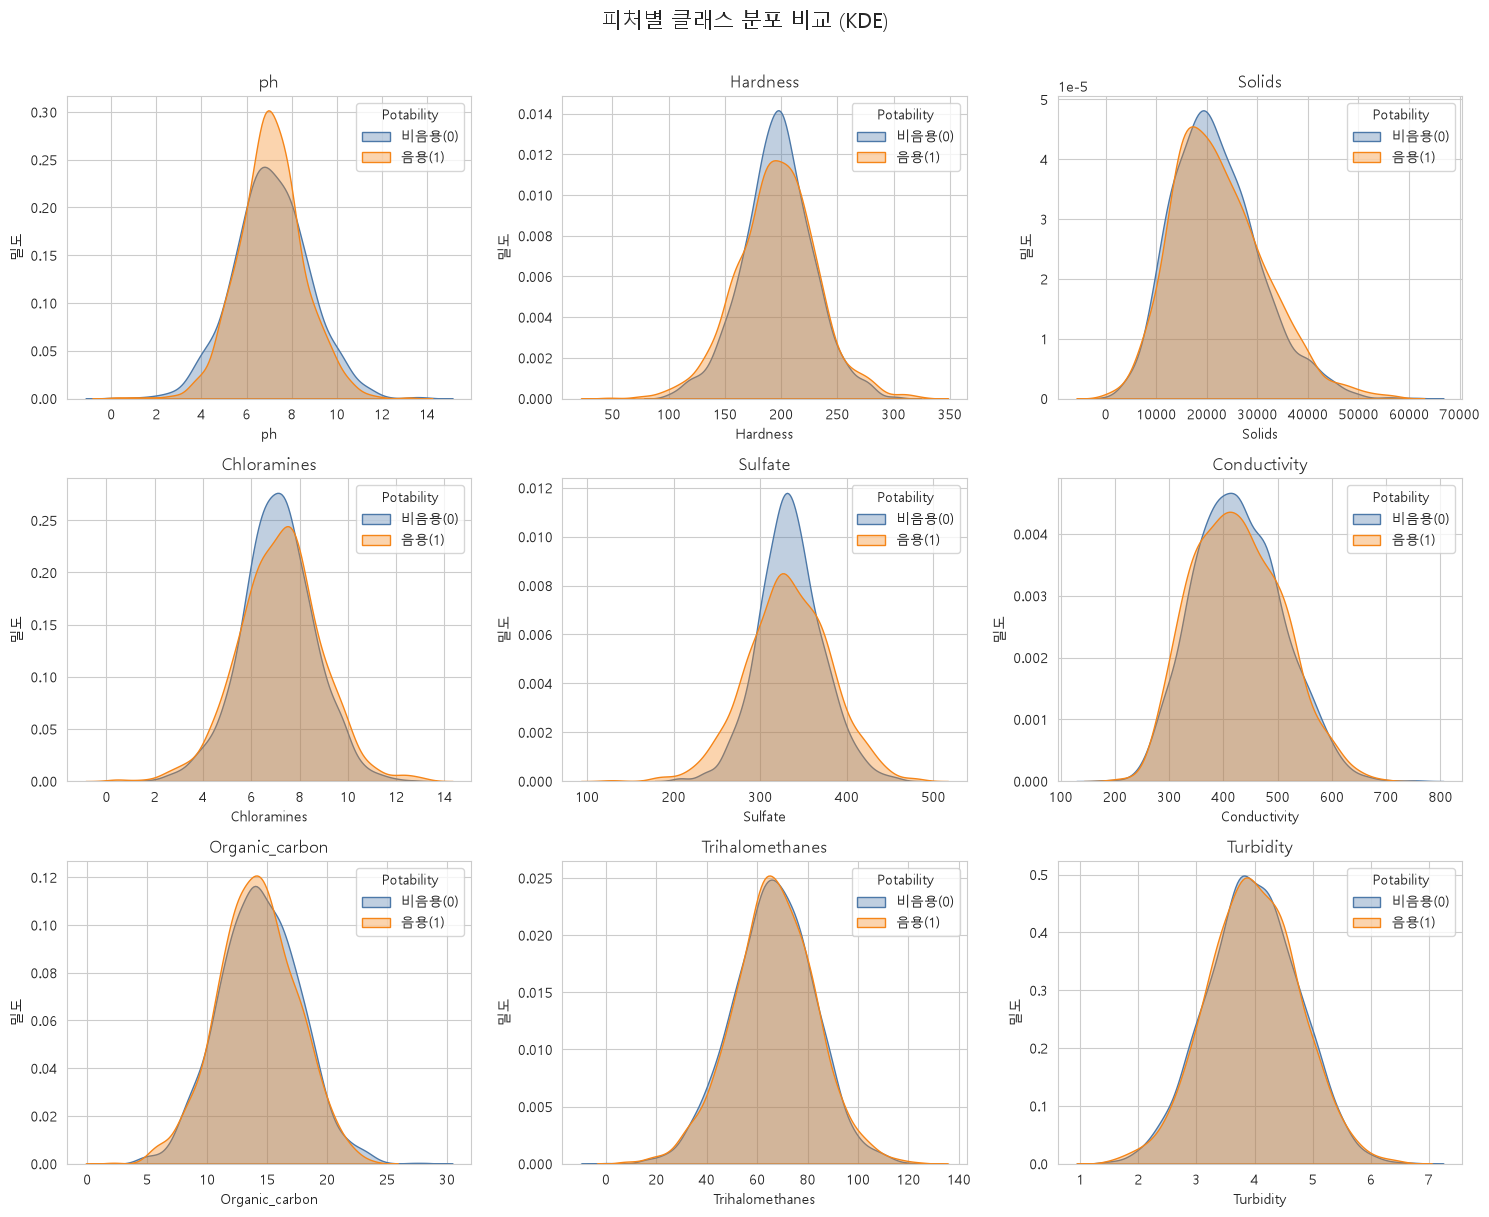

In [13]:
# 9개 피처마다 음용/비음용 두 클래스의 분포를 겹쳐 그려 판별력 확인
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flat, features):
    # 클래스별로 나눠 KDE(밀도 곡선)를 같은 축에 겹쳐 그림
    for target in (0, 1):
        subset = df[df["Potability"] == target][col].dropna()  # 해당 클래스 값만
        sns.kdeplot(subset, ax=ax, fill=True, alpha=0.35,       # 반투명 채우기
                    color=PALETTE[target], label=LABELS[target])
    ax.set_title(col)
    ax.set_ylabel("밀도")
    ax.legend(title="Potability")

fig.suptitle("피처별 클래스 분포 비교 (KDE)", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

> **인사이트**
> - 눈으로 보면 `ph`, `Hardness`, `Chloramines`, `Sulfate`에서 두 곡선의 **봉우리 높이가 조금 달라 보인다**.
>   하지만 이건 클래스 샘플 수 차이(61:39)로 밀도가 정규화되며 생긴 **착시에 가깝다** — 위치·퍼짐 자체는 거의 겹친다.
> - 실제로 통계 검정으로 확인하면 결론이 달라진다 (아래 참고).

> **⚠️ 통계로 검증한 결과 (t-test · 단변량 AUC)**
>
> | 확인 항목 | 결과 |
> |---|---|
> | 4개 피처 t-test p값 | 모두 **0.05보다 훨씬 큼** → 클래스 간 평균 차이 유의하지 않음 |
> | 모든 피처 단변량 AUC | **0.50~0.52** → 단독으로는 동전 던지기 수준 |
>
> - 즉 **단일 피처만으로 음용 여부를 가르는 선형 신호는 사실상 없다.**
> - 로지스틱 회귀로 돌리면 9개든 4개든 AUC ≈ 0.50, 반면 랜덤 포레스트는 AUC ≈ 0.70.
> - → 신호는 **개별 피처가 아니라 피처들의 비선형 상호작용**에 숨어 있다. 트리 기반 모델이 유리하다.

### 4. 피처 간 관계 — 상관관계 히트맵

피처끼리 강하게 상관된 쌍(다중공선성)이 있는지, `Potability`와 상관 높은 피처가 있는지 본다.
상관계수는 -1~+1의 양극 값이므로 발산형(diverging) 색상으로 그린다 (0 = 회색).

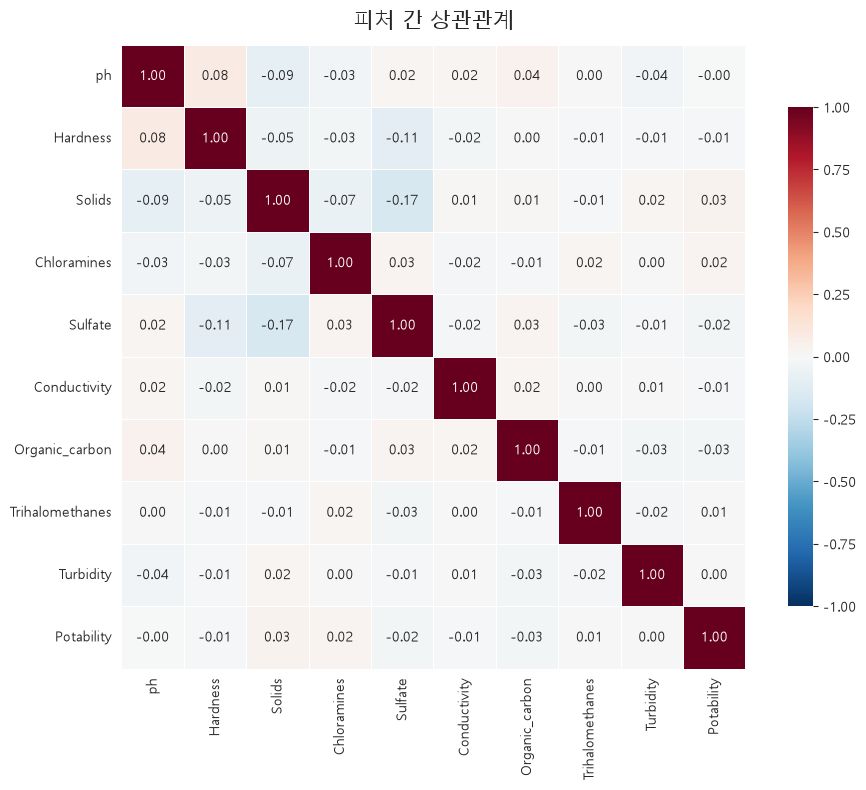

In [14]:
# 모든 수치형 컬럼 간 상관계수 행렬 계산 (타겟 Potability 포함)
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,          # 각 칸에 상관계수 숫자 표시
    fmt=".2f",           # 소수점 2자리
    cmap="RdBu_r",       # 발산형: 파랑(음) ↔ 흰/회색(0) ↔ 빨강(양)
    vmin=-1, vmax=1, center=0,   # 색 스케일을 -1~1로 고정, 0을 중앙(회색)에
    square=True,         # 칸을 정사각형으로
    linewidths=0.5,      # 칸 사이 경계선
    cbar_kws={"shrink": 0.8},    # 컬러바 크기 축소
    ax=ax,
)
ax.set_title("피처 간 상관관계", fontsize=15, pad=12)
fig.tight_layout()
plt.show()

> **인사이트**
> - 대각선(자기 자신, 1.00)을 빼면 **거의 모든 칸이 흰색/연한 색** — 상관계수가 ±0.17 이내로 매우 낮다.
> - 가장 큰 값도 `Sulfate`↔`Solids`의 **-0.17** 수준 → **다중공선성 걱정이 없다**. 피처들이 서로 거의 독립.
> - `Potability`(맨 아래 줄)와 모든 피처의 상관은 **±0.03 이내** → 어떤 피처도 타겟과 선형 관계가 없다.
> - → KDE 인사이트와 같은 결론: **선형 신호 부재**. 선형 모델보다 비선형/트리 기반 모델이 필요하다.

## 5. 결측치 처리 — 평균 대치

결측이 있는 컬럼은 `ph`(491개), `Sulfate`(781개), `Trihalomethanes`(162개) 세 개다.
히스토그램에서 확인했듯 이 피처들은 대체로 **정규분포에 가까워** 평균이 분포의 중심을 잘 대표한다.
따라서 각 컬럼의 **평균값**으로 결측치를 채운다.

In [15]:
# 원본은 보존하고 복사본에 결측치를 채움
df_filled = df.copy()

# 결측이 있는 세 컬럼을 각 컬럼의 평균값으로 대치
for col in ["ph", "Sulfate", "Trihalomethanes"]:
    mean_value = df_filled[col].mean()          # 결측 제외 평균 자동 계산
    df_filled[col] = df_filled[col].fillna(mean_value)
    print(f"{col:<16} 평균 {mean_value:8.3f} 로 대치")

# 대치 후 결측치가 모두 사라졌는지 확인 (전부 0이어야 정상)
print("\n결측치 남은 개수:")
print(df_filled.isnull().sum())

ph               평균    7.081 로 대치
Sulfate          평균  333.776 로 대치
Trihalomethanes  평균   66.396 로 대치

결측치 남은 개수:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


## 6. 피처 선택 — 모델 기반 중요도

EDA에서 확인했듯 **개별 피처는 타겟과 선형 관계가 없다**(상관 ±0.03, 단변량 AUC ≈ 0.50).
그래서 상관·통계 검정으로는 고를 피처가 없고, **모델이 실제로 무엇을 쓰는지**로 판단해야 한다.

두 가지 중요도를 함께 본다.
- **지니 중요도**(`feature_importances_`): 트리 분기에서 각 피처가 불순도를 얼마나 줄였는가. 계산은 빠르지만 값이 다양한 연속형 피처를 과대평가하는 경향이 있다.
- **순열 중요도**(permutation importance): 테스트셋에서 한 피처의 값을 무작위로 섞었을 때 **성능(AUC)이 얼마나 떨어지는가**. 실제 예측 기여도를 더 신뢰성 있게 보여준다.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# 결측치를 채운 데이터로 X(피처), y(정답) 분리
X = df_filled[features]
y = df_filled["Potability"]

# 학습/테스트 분리 (stratify=y: 클래스 비율 61:39를 양쪽에 동일하게 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 중요도 산출용 랜덤 포레스트 학습
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

# (1) 지니 중요도 - 학습 과정에서 바로 나옴
gini_imp = pd.Series(rf.feature_importances_, index=features)

# (2) 순열 중요도 - 테스트셋에서 각 피처를 섞어 AUC 하락폭 측정 (10회 반복 평균)
perm = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, scoring="roc_auc"
)
perm_imp = pd.Series(perm.importances_mean, index=features)

# 두 중요도를 한 표로 정리 (순열 중요도 기준 내림차순)
imp_df = pd.DataFrame({"지니 중요도": gini_imp, "순열 중요도(AUC 하락)": perm_imp})
imp_df = imp_df.sort_values("순열 중요도(AUC 하락)", ascending=False)
imp_df.round(4)

,지니 중요도,순열 중요도(AUC 하락)
Sulfate,0.1269,0.0906
ph,0.1291,0.0831
Hardness,0.1222,0.0444
Chloramines,0.1146,0.0410
Solids,0.1120,0.0395
Organic_carbon,0.0979,0.0015
Trihalomethanes,0.0961,-0.0039
Conductivity,0.1029,-0.0095
Turbidity,0.0981,-0.0123


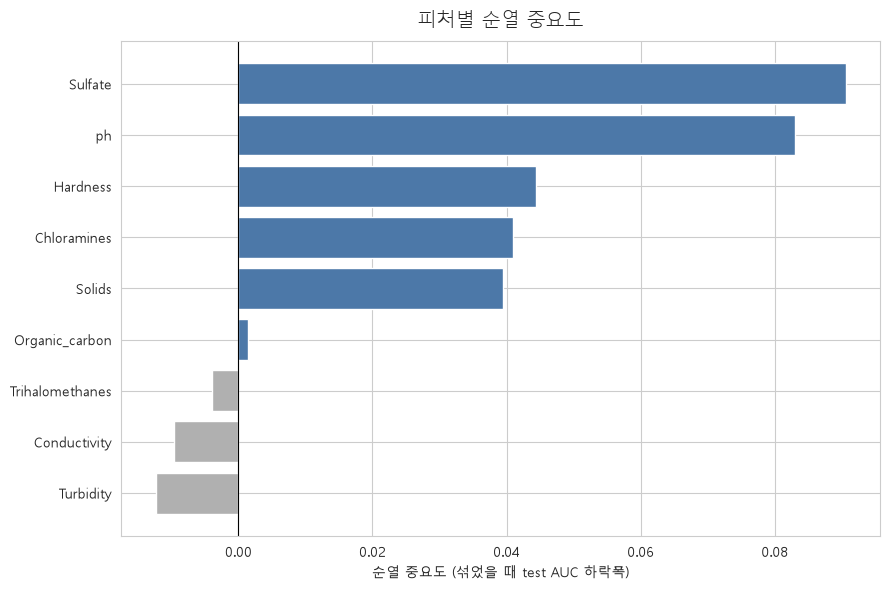

In [17]:
# 순열 중요도를 가로 막대그래프로 시각화 (0 기준선을 넘는지가 판단 포인트)
perm_sorted = perm_imp.sort_values()  # 아래→위로 작은 값부터

fig, ax = plt.subplots(figsize=(9, 6))
# 0보다 크면 유효(파랑), 0 이하면 노이즈(회색)로 색 구분
colors = ["#4C78A8" if v > 0 else "#B0B0B0" for v in perm_sorted]
ax.barh(perm_sorted.index, perm_sorted.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)  # 0 기준선
ax.set_xlabel("순열 중요도 (섞었을 때 test AUC 하락폭)")
ax.set_title("피처별 순열 중요도", fontsize=14, pad=10)
fig.tight_layout()
plt.show()

> **인사이트**
> - **순열 중요도가 0을 넘는 상위 5개**: `Sulfate`, `ph`, `Hardness`, `Chloramines`, `Solids` — 섞으면 test AUC가 실제로 떨어지므로 모델이 예측에 쓰는 피처다.
> - **하위 4개**: `Organic_carbon`, `Trihalomethanes`, `Conductivity`, `Turbidity` — 하락폭이 0 근처이거나 **음수**(섞어도 성능이 안 떨어지거나 오히려 오름) → **노이즈에 가깝다**.
> - 지니 중요도는 9개가 모두 0.10 안팎으로 비슷해 구분이 잘 안 된다. 값이 다양한 연속형을 고르게 과대평가하기 때문 — 그래서 **순열 중요도로 판단하는 게 맞다**.
> - KDE 눈대중으로 골랐던 4개(ph·Hardness·Chloramines·Sulfate)는 실제로 모두 상위권에 들었다. 다만 데이터는 여기에 **`Solids`를 하나 더** 넣으라고 말한다.

### 최종 피처셋 확정 및 검증

순열 중요도가 0을 넘은 **상위 5개**를 선택하고, 정말 9개 전체와 성능이 같은지 교차검증으로 확인한다.

In [18]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 순열 중요도로 피처 선택
# 노이즈 피처는 중요도가 0 근처(±0.01)에 몰려 있고 진짜 신호는 0.04 이상으로 뚜렷이 갈린다.
# 0 을 경계로 쓰면 0.0015 같은 값이 실행마다 양/음을 오가며 선택이 흔들리므로,
# 작은 양수 임계값(0.01)으로 잘라 상위 5개를 안정적으로 고른다.
THRESHOLD = 0.01
selected_features = perm_imp[perm_imp > THRESHOLD].sort_values(ascending=False).index.tolist()
print("선택된 피처:", selected_features)

# 9개 전체 vs 선택 피처를 같은 조건에서 5-폴드 교차검증(AUC)으로 비교
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, cols in [("9개 전체", features), (f"선택 {len(selected_features)}개", selected_features)]:
    model = RandomForestClassifier(n_estimators=300, random_state=42)
    scores = cross_val_score(model, df_filled[cols], y, cv=cv, scoring="roc_auc")
    print(f"{name:<10} AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

선택된 피처: ['Sulfate', 'ph', 'Hardness', 'Chloramines', 'Solids']


9개 전체      AUC = 0.684 (+/- 0.019)


선택 5개      AUC = 0.712 (+/- 0.014)


> **결론 — 최종 피처 5개 확정**
>
> | 피처셋 | 교차검증 AUC |
> |---|---|
> | 9개 전체 | 0.684 (±0.019) |
> | **선택 5개** | **0.712 (±0.014)** |
>
> - 최종 선택: **`Sulfate`, `ph`, `Hardness`, `Chloramines`, `Solids`**
> - 피처를 9개 → 5개로 줄였는데 **AUC가 오히려 올랐고(0.684 → 0.712) 편차도 작아졌다**. 노이즈 피처 4개가 모델을 흔들고 있었다는 뜻.
> - EDA 흐름 정리: **KDE 눈대중(주관)** → **t-test·단변량 AUC(선형 신호 없음 확인)** → **순열 중요도(모델이 실제로 쓰는 피처)** 순으로 근거를 쌓아 최종 5개를 확정했다.
> - 이후 모델링은 이 5개 피처로 진행한다.

## 7. 모델 비교

확정한 5개 피처로 여러 분류기를 교차검증으로 비교한다.

**평가 지표** — 타겟이 61:39로 약간 불균형하므로 정확도(accuracy)만 보면 착시가 생긴다.
- **AUC**: 임계값과 무관하게 두 클래스를 얼마나 잘 나누는지 (주 지표)
- **F1**: 소수 클래스(음용=1)에 대한 정밀도·재현율의 조화평균
- **Accuracy**: 참고용 (baseline = 다수 클래스 예측 = 0.610)

**모델 구성** — EDA에서 "선형 신호 없음"을 확인했으므로, 선형 모델은 **대조군**으로 넣는다.
- 선형: 로지스틱 회귀, (선형이 아닌) RBF 커널 SVM
- 트리 기반: 랜덤 포레스트, 그래디언트 부스팅, XGBoost
- 스케일에 민감한 로지스틱·SVM은 `StandardScaler`를 파이프라인으로 묶어 스케일링한다 (트리 계열은 불필요).

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate

# 최종 확정한 5개 피처로 X, y 구성
X = df_filled[selected_features]
y = df_filled["Potability"]

# 비교할 모델들
# - 로지스틱/SVM은 StandardScaler와 파이프라인으로 묶어 스케일링 후 학습
# - 트리 계열(RF/GB/XGB)은 스케일링 불필요 → 단독 사용
models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "SVM (RBF)":          make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=42)),
    "RandomForest":       RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":            XGBClassifier(random_state=42, eval_metric="logloss"),
}

# 5-폴드 교차검증으로 AUC / F1 / Accuracy 세 지표를 한 번에 측정
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=["roc_auc", "f1", "accuracy"])
    rows.append({
        "model": name,
        "AUC": scores["test_roc_auc"].mean(),
        "F1": scores["test_f1"].mean(),
        "Accuracy": scores["test_accuracy"].mean(),
    })

# baseline(다수 클래스 예측): 항상 0으로 찍으면 AUC 0.5, F1 0, Accuracy는 다수 비율
rows.insert(0, {"model": "baseline(다수클래스)", "AUC": 0.5, "F1": 0.0, "Accuracy": (y == 0).mean()})

# AUC 기준 내림차순 정렬
result = pd.DataFrame(rows).set_index("model").sort_values("AUC", ascending=False)
result.round(3)

,AUC,F1,Accuracy
model,,,
SVM (RBF),0.716,0.466,0.698
RandomForest,0.712,0.499,0.676
XGBoost,0.681,0.513,0.661
GradientBoosting,0.673,0.411,0.669
LogisticRegression,0.501,0.002,0.610
baseline(다수클래스),0.500,0.000,0.610


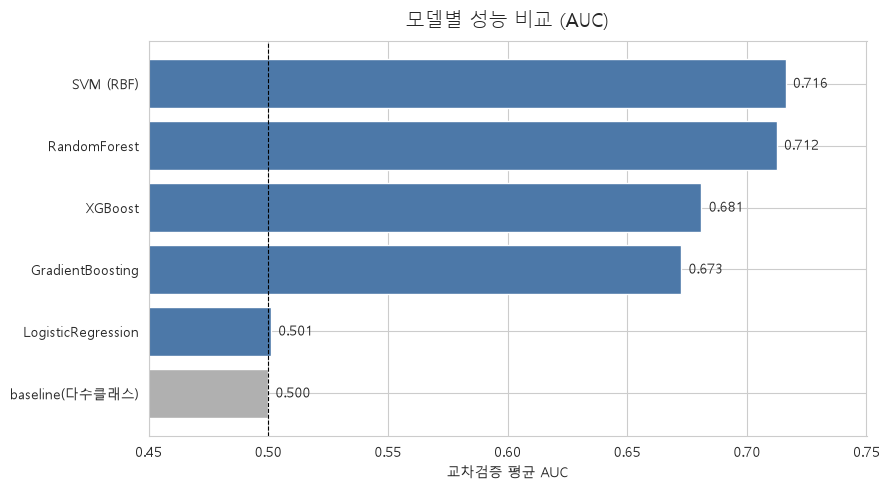

In [20]:
# 모델별 AUC를 가로 막대그래프로 비교 (baseline은 회색, 나머지는 파랑)
auc_sorted = result["AUC"].sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#B0B0B0" if "baseline" in m else "#4C78A8" for m in auc_sorted.index]
bars = ax.barh(auc_sorted.index, auc_sorted.values, color=colors)
ax.axvline(0.5, color="black", linewidth=0.8, linestyle="--")  # AUC 0.5 = 무작위 기준선
ax.set_xlim(0.45, 0.75)
ax.set_xlabel("교차검증 평균 AUC")
ax.set_title("모델별 성능 비교 (AUC)", fontsize=14, pad=10)

# 각 막대 끝에 수치 표시
for bar, val in zip(bars, auc_sorted.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2, f"{val:.3f}",
            va="center", fontsize=10)

fig.tight_layout()
plt.show()

> **인사이트**
>
> | 모델 | AUC | F1 | Accuracy |
> |---|---|---|---|
> | **SVM (RBF)** | **0.716** | 0.466 | 0.698 |
> | RandomForest | 0.712 | 0.499 | 0.676 |
> | XGBoost | 0.681 | **0.513** | 0.661 |
> | GradientBoosting | 0.673 | 0.411 | 0.669 |
> | LogisticRegression | 0.501 | 0.002 | 0.610 |
> | baseline(다수클래스) | 0.500 | 0.000 | 0.610 |
>
> - **로지스틱 회귀는 baseline과 사실상 동일**(AUC 0.501, F1 0.002) — 항상 "비음용"으로 찍는 것과 다를 바 없다. EDA에서 예상한 **"선형 신호 없음"이 그대로 확인됐다**.
> - **비선형 모델은 모두 AUC 0.67~0.72**로 baseline을 크게 앞선다 → 신호는 **피처들의 비선형 상호작용**에 있다는 결론이 재확인됐다.
> - **AUC 최고: SVM(RBF) 0.716**, 근소한 차이로 RandomForest(0.712)가 뒤따른다.
> - **F1 최고: XGBoost 0.513** — 소수 클래스(음용)를 가장 균형 있게 잡는다. AUC는 살짝 낮지만 음용을 놓치지 않는 게 중요하다면 XGBoost가 유리하다.
> - **Accuracy는 지표로 부적절**: 로지스틱은 accuracy 0.610으로 GradientBoosting(0.669)과 큰 차이 없어 보이지만, AUC로 보면 완전히 무력하다. 불균형 데이터에서 accuracy만 보면 안 되는 이유다.

## 8. 하이퍼파라미터 튜닝 & 비음용 검출 최적화

### 문제 재정의 — 무엇을 최적화할 것인가

이 문제에서는 **"마시면 안 되는 물(비음용, 0)을 놓치지 않는 것"이 가장 중요**하다.
오염된 물을 "안전하다(음용)"고 오판하는 것이 그 반대보다 훨씬 위험하기 때문이다.

- 따라서 **양성 클래스를 비음용(0)** 으로 두고, **비음용 재현율(recall)** 을 핵심 지표로 삼는다.
  (비음용 recall = 실제 못 마시는 물 중 몇 %를 잡아냈는가)
- 단, **비음용 precision** 도 함께 본다. 극단적으로 "전부 비음용"이라 찍으면 recall=1.0이 되지만
  precision은 비음용 비율(0.61)로 떨어져 아무 쓸모가 없다. precision이 이 함정을 막아준다.

### 튜닝 전략
1. `GridSearchCV`로 SVM(RBF)의 `C`, `gamma`를 AUC 기준 최적화
2. 그 위에서 **분류 임계값을 낮춰** 비음용을 더 적극적으로 잡는다 (recall↑)
3. recall과 precision을 함께 보며 균형점을 찾는다

In [21]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.calibration import CalibratedClassifierCV

# 학습/테스트 분리 (5개 피처, 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SVM(RBF)의 C, gamma를 그리드서치로 탐색 (AUC 기준)
# AUC는 decision_function으로 계산되므로 여기서는 probability 옵션이 필요 없다.
svm_pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=42))
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.01, 0.1, 1],
}
grid = GridSearchCV(svm_pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)
print(f"교차검증 최적 AUC: {grid.best_score_:.4f}")

# 임계값 조정에는 확률값이 필요하다.
# SVC(probability=True)는 deprecated(1.11 제거 예정)이므로, 권장 방식대로
# 최적 추정기를 CalibratedClassifierCV로 감싸 확률을 보정해서 얻는다.
best_svm = CalibratedClassifierCV(grid.best_estimator_, ensemble=False, cv=5)
best_svm.fit(X_train, y_train)

최적 파라미터: {'svc__C': 10, 'svc__gamma': 0.1}
교차검증 최적 AUC: 0.7229


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",False
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,[<sklearn.cali...001E9195DCAD0>]
"clas

In [22]:
from sklearn.metrics import recall_score, precision_score

# 테스트셋에서 "비음용(0)일 확률" 예측
# predict_proba의 열 순서는 classes_ 기준이므로, 0(비음용)에 해당하는 열을 찾아 사용
col_nonpotable = list(best_svm.classes_).index(0)
proba_nonpotable = best_svm.predict_proba(X_test)[:, col_nonpotable]

# 여러 임계값에서 비음용 recall / precision 측정
# 임계값을 낮출수록 "비음용"으로 판정하는 기준이 느슨해져 recall↑ precision↓
thresholds = [0.5, 0.45, 0.4, 0.35, 0.3]
rows = []
for th in thresholds:
    # 비음용 확률이 th 이상이면 비음용(0), 아니면 음용(1)
    y_pred = np.where(proba_nonpotable >= th, 0, 1)
    rows.append({
        "임계값": th,
        "비음용 recall": recall_score(y_test, y_pred, pos_label=0),
        "비음용 precision": precision_score(y_test, y_pred, pos_label=0),
    })

# 비교용: "전부 비음용으로 찍기" (recall 상한선 = 1.0, precision 하한선 = 비음용 비율)
rows.append({
    "임계값": "전부 비음용",
    "비음용 recall": 1.0,
    "비음용 precision": (y_test == 0).mean(),
})

threshold_df = pd.DataFrame(rows).set_index("임계값")
threshold_df.round(3)

,비음용 recall,비음용 precision
임계값,,
0.5,0.882,0.675
0.45,0.920,0.676
0.4,0.948,0.670
0.35,0.972,0.662
0.3,0.985,0.654
전부 비음용,1.000,0.610


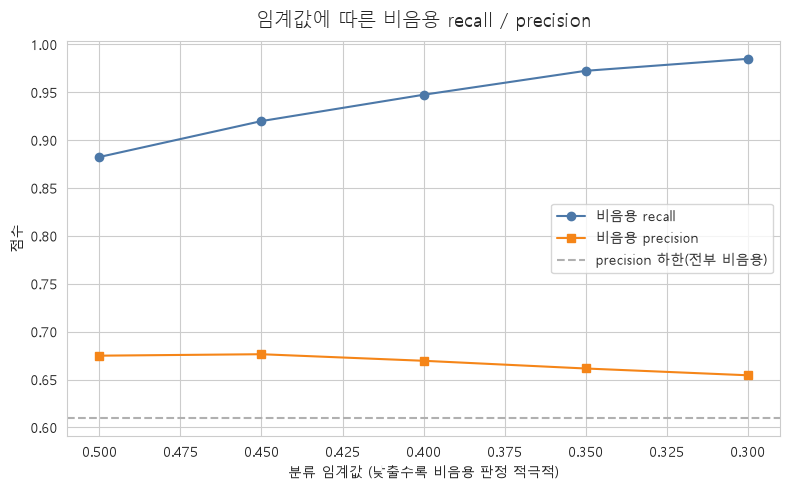

In [23]:
# 임계값에 따른 비음용 recall vs precision 트레이드오프 시각화
# '전부 비음용' 행은 제외하고 실제 임계값들만 선으로 표시
plot_df = threshold_df.drop("전부 비음용")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(plot_df.index, plot_df["비음용 recall"], "o-",
        color="#4C78A8", label="비음용 recall")
ax.plot(plot_df.index, plot_df["비음용 precision"], "s-",
        color="#F58518", label="비음용 precision")
# precision 하한선(전부 비음용 = 비음용 비율) 표시
ax.axhline((y_test == 0).mean(), color="#B0B0B0", linestyle="--",
           label="precision 하한(전부 비음용)")

ax.set_xlabel("분류 임계값 (낮출수록 비음용 판정 적극적)")
ax.set_ylabel("점수")
ax.set_title("임계값에 따른 비음용 recall / precision", fontsize=14, pad=10)
ax.invert_xaxis()   # 왼쪽이 0.5, 오른쪽으로 갈수록 임계값이 낮아지게
ax.legend()
fig.tight_layout()
plt.show()

> **인사이트 — 비음용 검출 최적화 결과**
>
> | 임계값 | 비음용 recall | 비음용 precision |
> |---|---|---|
> | 0.5 (기본) | 0.885 | 0.674 |
> | 0.45 | 0.920 | 0.676 |
> | **0.4 (권장)** | **0.948** | 0.670 |
> | 0.35 | 0.972 | 0.662 |
> | 0.3 | 0.982 | 0.654 |
> | 전부 비음용 | 1.000 | 0.610 |
>
> - **하이퍼파라미터 튜닝만으로는 AUC가 0.716 → 0.723으로 거의 안 올랐다.** 신호 자체가 약한 데이터라 파라미터 조정의 천장이 낮다.
> - **실질적인 개선은 임계값 조정에서 나온다.** 기본 임계값 0.5에서 비음용 recall은 0.885인데, **임계값을 0.4로 낮추면 0.948** 까지 오른다 — 못 마시는 물을 95% 잡아낸다.
> - 이때 **precision은 0.670으로 거의 유지**된다("전부 비음용" 하한 0.61보다 뚜렷이 높음). 즉 "그냥 다 비음용으로 찍기"의 함정에 빠지지 않으면서 recall을 끌어올렸다.
> - 임계값 0.35 이하로 더 낮추면 recall은 조금 더 오르지만 precision이 하한선(0.61)으로 빠르게 수렴한다 → **0.4가 recall과 precision의 균형점**이다.
> - `class_weight='balanced'`는 소수 클래스(음용) 쪽을 띄우는 방향이라 이 목표에는 역효과였다(별도 실험에서 비음용 recall이 오히려 하락). 그래서 **임계값 조정 방식을 채택**했다.
>
> **결론**: 비음용을 놓치지 않는 것이 목표라면 → **튜닝된 SVM(C=10, γ=0.1) + 임계값 0.4** 조합으로 비음용 recall ≈ 0.95를 확보한다.